<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/01**


# **Entrega 3**

---

# **Titulo do Projeto**: Previsão de doenças respiratórias baseado em análise de séries temporais da poluição atmosférica no estado de São Paulo

---

In [30]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'André Dalle Vedove Canassa, 10415817'   #@param {type:"string"}
Aluno2 = 'Otavio Bernardo Scandiuzzi, 10407867'  #@param {type:"string"}
Aluno3 = 'Valdo Alvim da Rocha Junior, 10414936'  #@param {type:"string"}
Aluno4 = 'Victor José de Souza Teodoro, 10414609' #@param {type:"string"}


# **Introdução**

A qualidade do ar é um fator determinante para a saúde pública, influenciando diretamente o bem-estar da população e a incidência de doenças respiratórias e cardiovasculares (BRAGA et al., 2001). A exposição a poluentes atmosféricos pode acarretar impactos significativos, principalmente em grupos vulneráveis, como crianças, idosos e pessoas com condições preexistentes (CETESB, 2022). No contexto do estado de São Paulo, a alta densidade populacional e a intensa atividade industrial e veicular contribuem para elevados níveis de poluição do ar, tornando essencial a análise de padrões de concentração desses poluentes ao longo do tempo.

Este estudo propõe a aplicação de técnicas de análise de séries temporais para investigar a evolução da poluição atmosférica no estado de São Paulo, com ênfase em sua relação com indicadores de saúde pública. O objetivo é fornecer informações que subsidiem políticas públicas voltadas para a mitigação dos efeitos nocivos da poluição na saúde da população.

A poluição do ar está diretamente associada ao aumento de internações hospitalares e mortalidade por doenças respiratórias e cardiovasculares (BRAGA et al., 2001). Segundo a Organização Mundial da Saúde (OMS), cerca de 7 milhões de mortes prematuras por ano estão relacionadas à exposição a poluentes atmosféricos (WHO, 2021). Em São Paulo, estudos indicam que episódios de alta concentração de material particulado (MP10 e MP2,5) estão correlacionados a um crescimento significativo nos atendimentos por problemas respiratórios (CETESB, 2022).

A análise de séries temporais pode contribuir para a identificação de padrões e tendências nos níveis de poluição, possibilitando a implementação de medidas preventivas e a otimização de recursos na área da saúde. Além disso, compreender a relação entre poluição atmosférica e indicadores de saúde permite o desenvolvimento de estratégias de mitigação mais eficazes, beneficiando diretamente a qualidade de vida da população.

Este projeto tem como objetivo principal analisar os padrões temporais da poluição atmosférica no estado de São Paulo e sua relação com indicadores de saúde pública. Para alcançar esse objetivo geral, foram definidos os seguintes objetivos específicos:

- Coletar e organizar dados de qualidade do ar e de internações hospitalares;
- Identificar padrões e sazonalidades nos níveis de poluição e hospitalizações;
- Avaliar a correlação entre os poluentes atmosféricos e as internações hospitalares;
- Desenvolver um modelo preditivo para estimar a demanda hospitalar com base na qualidade do ar;
- Fornecer subsídios para políticas de saúde e ambiental voltadas à prevenção de doenças respiratória.

Para este estudo, foi utilizada uma base de dados contendo registros de concentração de poluentes atmosféricos no estado de São Paulo (IEMA, 2025), coletados entre 2015 e 2021. Os dados foram obtidos a partir da Companhia Ambiental do Estado de São Paulo (CETESB), responsável pelo monitoramento contínuo da qualidade do ar na região.

A base de dados é composta por mais de 10 milhões de registros provenientes de 87 estações de monitoramento distribuídas pelo estado. Os principais atributos da base incluem:

- **ID**: Identificação única de cada registro (categórico, nominal);
- **Data**: Data da medição da concentração do poluente (categórico, ordinal);
- **Hora**: Horário da medição (categórico, ordinal);
- **Estação**: Local onde a medição foi realizada (categórico, nominal);
- **Código**: Código da estação de medição (categórico, nominal);
- **Poluente**: Tipo de poluente monitorado (categórico, nominal);
- **Valor**: Concentração do poluente medida (numérico, contínuo);
- **Unidade**: Unidade de concentração utilizada (categórico, nominal);
- **Tipo**: Método de medição (automático ou manual) (categórico, nominal).

Além dos dados de qualidade do ar, serão utilizados registros do valor total gasto com internações hospitalares por doenças respiratórias no estado de São Paulo, obtidos a partir do Datasus.

A base de dados obtida a partir do Datasus contém as informações de internações hospitalares do SUS no município de São Paulo a partir de 2008, e foi extraída com os seguintes filtros:

- **Linha**: Mês/Ano de Competência;
- **Coluna**: Diagnóstico Principal Interno(CID-10);
- **Conteúdo**: Valor Total Pago em AIHs(Autorização de Internação Hospitalar);
- **Tipo de AIH**: Normal (categórico, nominal);
- **Diag.princ.intern.(CID-10-Cap)**: X.Doença do aparelho respiratório;

Os principais atributos da base incluem:

- **Mês/Ano de Competência**: Contém o mês e ano de referência. (categórico, ordinal);
- **Cap 10**: Valor gasto com internações de doença do aparelho respiratório. (numérico, contínuo);

In [9]:
import pandas as pd

df1 = pd.read_parquet("../dados/SP_poluicao_part1.parquet")
df2 = pd.read_parquet("../dados/SP_poluicao_part2.parquet")

poluicao_sp = pd.concat([df1, df2], ignore_index=True)
poluicao_sp = poluicao_sp.sort_values(by='Data', ascending=True)
poluicao_sp = poluicao_sp.drop(['Unnamed: 0'], axis=1)

poluicao_sp.head()

,ID,Data,Hora,Estacao,Codigo,Poluente,Valor,Unidade,Tipo
9938956,56492,2015-01-01,01:00,Bauru,SP06,MP10,47.0,ug/m3,automatica
10296422,413958,2015-01-01,12:00,Diadema,SP21,O3,86.0,ug/m3,automatica
10296423,413959,2015-01-01,13:00,Diadema,SP21,O3,83.0,ug/m3,automatica
10296424,413960,2015-01-01,14:00,Diadema,SP21,O3,85.0,ug/m3,automatica
10296425,413961,2015-01-01,15:00,Diadema,SP21,O3,83.0,ug/m3,automatica


In [7]:
df_sus = pd.read_csv("../dados/Dados_Infec_Resp_SP_2008-2023_SUS.csv", sep=';', encoding='latin1', index_col=False)

df_sus.head()

,Mês/ano de competência,Cap 10,Total
0,Jan/2008,"1038893,42","1038893,42"
1,Fev/2008,"2557701,43","2557701,43"
2,Mar/2008,"3050171,10","3050171,10"
3,Abr/2008,"4378555,04","4378555,04"
4,Mai/2008,"5793167,58","5793167,58"


# **Referencial Teórico**

A previsão de séries temporais é uma área fundamental da análise de dados, amplamente utilizada para antecipação de tendências em diversas aplicações, como qualidade do ar, economia e demanda energética. Segundo Jalili et al. (2020), métodos tradicionais como ARIMA são eficazes para padrões lineares, mas possuem limitações na captura de não-linearidades.

De acordo com Parmezan, Souza e Batista (2019), a escolha do algoritmo mais promissor para modelar e prever fenômenos é uma das atividades mais proeminentes da previsão de dados temporais. O estudo conduzido por esses autores apresenta uma das avaliações experimentais mais abrangentes já realizadas, envolvendo 95 conjuntos de dados e 11 algoritmos preditivos (sete paramétricos e quatro não paramétricos). Eles utilizaram duas estratégias de projeção de múltiplos passos à frente e quatro medidas de desempenho para comparar os modelos.

Os resultados mostraram que o modelo SARIMA é o único modelo estatístico que conseguiu superar, embora sem diferença estatística significativa, algoritmos de aprendizado de máquina como ANN, SVM e kNN-TSPI. No entanto, a precisão de previsão obtida com SARIMA veio com o custo de um número maior de parâmetros. Este estudo ressaltou a importância de considerar as características específicas dos dados ao escolher o modelo preditivo adequado, especialmente quando se trata de dados com não-linearidades ou tendências sazonais.

O estudo de Slama et al. (2019) demonstra que a qualidade do ar impacta diretamente em internações hospitalares, reforçando a importância de previsão acurada de poluentes. Abordagens híbridas, combinando estatística e aprendizado de máquina, têm sido cada vez mais empregadas devido à sua capacidade de integrar diferentes fontes de dados e melhorar a precisão da previsão (ZHANG et al., 2012).

O trabalho de Gouveia e Fletcher (2000) revelou que a poluição atmosférica está fortemente associada a internações hospitalares em crianças devido a doenças respiratórias, com um impacto significativo da O3, NO2 e PM10 nas admissões hospitalares.


# **Diagrama de Solução**
Abaixo podemos ver um diagrama da solução proposta.


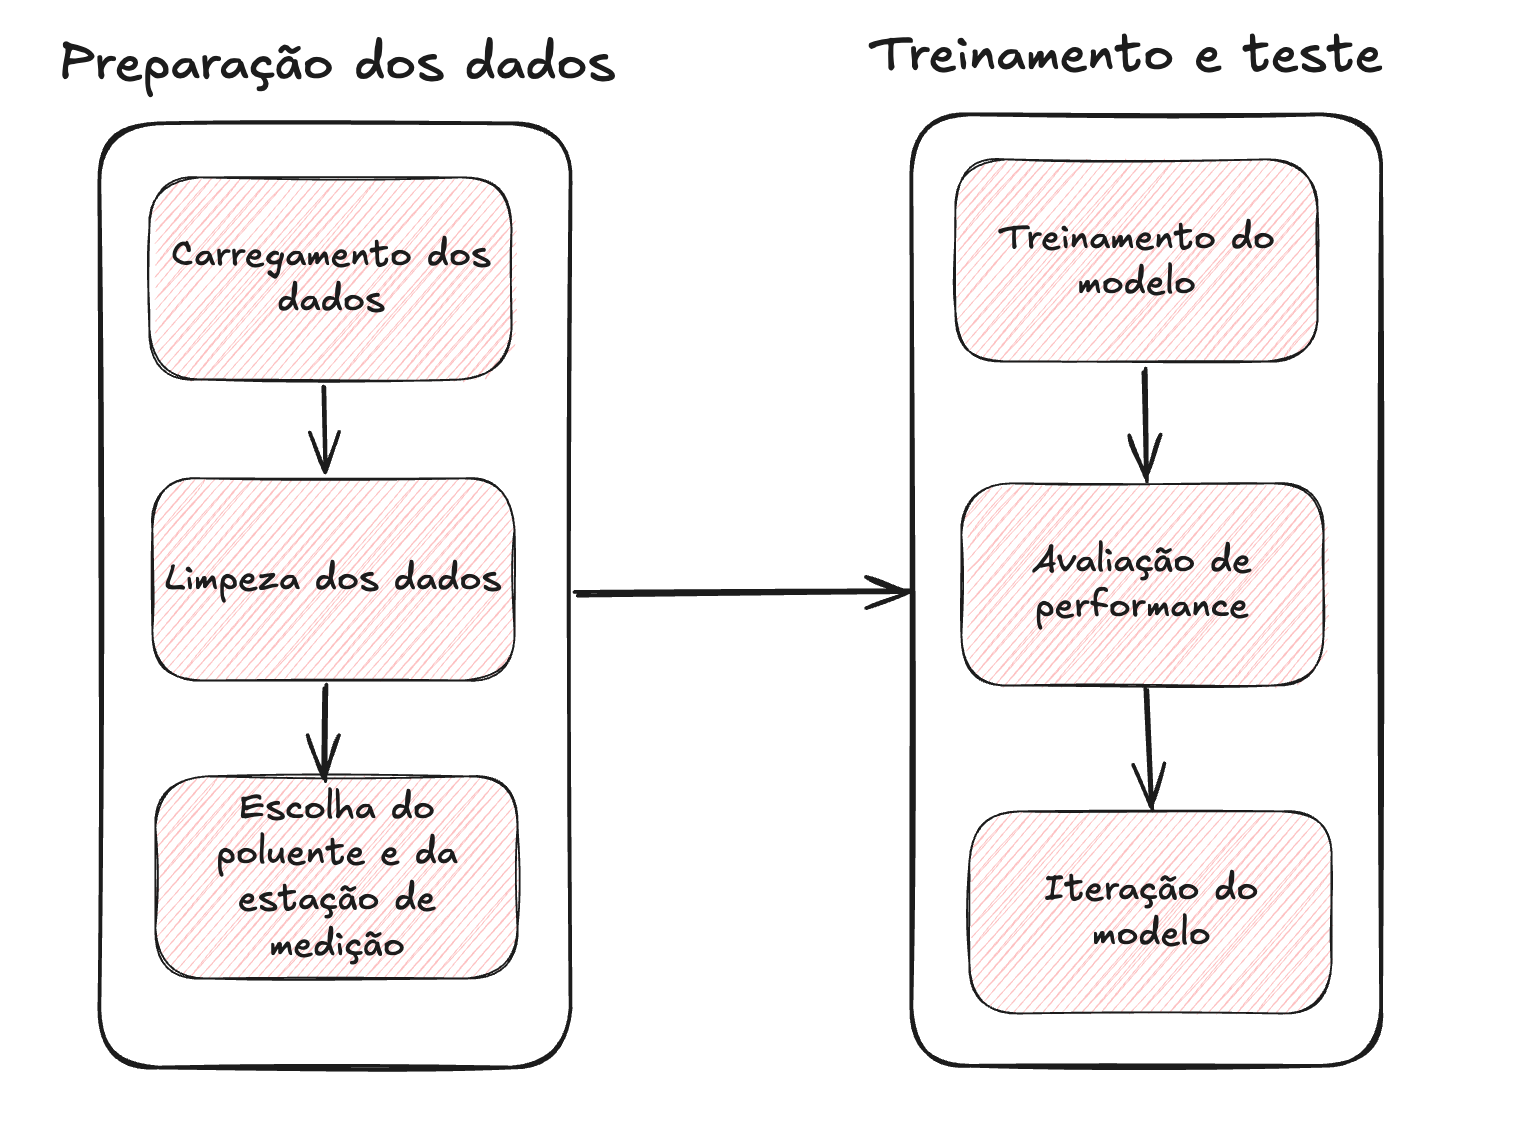

# **EDA e Pré-processamento dos dados**


## **Tratando os Dados de Poluição**

Abaixo podemos ver os dados de poluição utilizados. Ele foram dividios em 2 arquivos Parquet por questões de espaço (o Github não permite arquivos com mais de 100Mb).

In [1]:
import pandas as pd

df1 = pd.read_parquet("../dados/SP_poluicao_part1.parquet")
df2 = pd.read_parquet("../dados/SP_poluicao_part2.parquet")

poluicao_sp = pd.concat([df1, df2], ignore_index=True)
poluicao_sp = poluicao_sp.sort_values(by='Data', ascending=True)
poluicao_sp = poluicao_sp.drop(['Unnamed: 0'], axis=1)

poluicao_sp.head()

,ID,Data,Hora,Estacao,Codigo,Poluente,Valor,Unidade,Tipo
9938956,56492,2015-01-01,01:00,Bauru,SP06,MP10,47.0,ug/m3,automatica
10296422,413958,2015-01-01,12:00,Diadema,SP21,O3,86.0,ug/m3,automatica
10296423,413959,2015-01-01,13:00,Diadema,SP21,O3,83.0,ug/m3,automatica
10296424,413960,2015-01-01,14:00,Diadema,SP21,O3,85.0,ug/m3,automatica
10296425,413961,2015-01-01,15:00,Diadema,SP21,O3,83.0,ug/m3,automatica


Abaixo temos as estações de medição no Estado de São Paulo que podemos utlizar para medir os poluentes escolhidos. São 87 no total. Algumas na capital (Tatuapé, Pinheiros, &c), outras no interior (Santo André, Franca, &c).

In [2]:
estacoes = poluicao_sp['Estacao'].unique()
print(f"Há {len(estacoes)} estações de monitoramento de poluição do ar na base de dados.")
estacoes

Há 87 estações de monitoramento de poluição do ar na base de dados.


array(['Bauru', 'Diadema', 'Catanduva', 'Araçatuba',
       'Santos - Ponta da Praia', 'Marg. Tietê - Pte dos Remédios',
       'Taboão da Serra', 'Cid.Universitária USP - IPEN', 'Jundiaí',
       'Capão Redondo', 'Marília', 'Jaú', 'Americana - Vila Santa Maria',
       'Tatuí', 'São Caetano do Sul', 'Congonhas', 'Cerqueira César',
       'Interlagos', 'Carapicuíba', 'Mauá', 'Mooca', 'Ibirapuera',
       'Santo André - Paço Municipal', 'Cubatão - Vila Parisi',
       'Paulínia - Sul', 'Osasco', 'São José dos Campos', 'Araraquara',
       'Paulínia', 'Santos', 'Pinheiros', 'Santana', 'Santo Amaro',
       'Campinas - Centro', 'São Bernardo do Campo - Centro', 'Sorocaba',
       'Piracicaba', 'São Bernardo do Campo - Paulicéia',
       'Presidente Prudente', 'Cubatão - Vale do Mogi',
       'Nossa Senhora do Ó', 'Grajaú - Parelheiros', 'Cubatão - Centro',
       'Parque Dom Pedro II', 'Campos Elíseos',
       'Paulínia - Bairro Cascata', 'Paulínia - João Aranha',
       'Salto - Centro',

Os dados vão de 2015 a 2021 e são medidos de hora em hora.

In [3]:
poluicao_sp['Data'].agg(['min', 'max'])

min    2015-01-01
max    2021-12-31
Name: Data, dtype: object

In [5]:
poluicao_sp[(poluicao_sp['Estacao'] == 'Bauru') & (poluicao_sp['Data'] == '2015-01-01') & (poluicao_sp['Poluente'] == 'MP10')].sort_values(by='Hora', ascending=True)

,ID,Data,Hora,Estacao,Codigo,Poluente,Valor,Unidade,Tipo
9938956,56492,2015-01-01,01:00,Bauru,SP06,MP10,47.0,ug/m3,automatica
9938957,56493,2015-01-01,02:00,Bauru,SP06,MP10,44.0,ug/m3,automatica
9938958,56494,2015-01-01,03:00,Bauru,SP06,MP10,10.0,ug/m3,automatica
9938959,56495,2015-01-01,04:00,Bauru,SP06,MP10,12.0,ug/m3,automatica
9938960,56496,2015-01-01,05:00,Bauru,SP06,MP10,12.0,ug/m3,automatica
9938961,56497,2015-01-01,06:00,Bauru,SP06,MP10,16.0,ug/m3,automatica
9938962,56498,2015-01-01,07:00,Bauru,SP06,MP10,9.0,ug/m3,automatica
9938963,56499,2015-01-01,08:00,Bauru,SP06,MP10,7.0,ug/m3,automatica
9938964,56500,2015-01-01,09:00,Bauru,SP06,MP10,17.0,ug/m3,automatica
9938965,56501,2015-01-01,10:00,Bauru,SP06,MP10,5.0,ug/m3,automatica


Há 9 poluentes ao total na base de dados com os seguintes nomes.

In [5]:
poluentes = poluicao_sp['Poluente'].drop_duplicates().sort_values(ascending=True)

print(f"Há {len(poluentes)} poluentes na base de dados.")
poluentes

Há 9 poluentes na base de dados.


10545756       CO
7962954       FMC
9938956      MP10
10823329    MP2.5
3927803        NO
10143202      NO2
10296422       O3
7963284       PTS
7845211       SO2
Name: Poluente, dtype: object

## **Tratando os dados DataSUS**

Abaixo temos a base de dados do DataSUS. Diferentemente da base acima, precisamos limpar algumas entradas e converter as datas de medição para o formato `datetime` para pode compará-la com a base de poluentes.

In [8]:
# Carrega a base do SUS
df_sus = pd.read_csv("../dados/Dados_Infec_Resp_SP_2008-2023_SUS.csv", sep=';', encoding='latin1')

In [9]:
# Mantém apenas linhas no formato "xxx/yyyy"
df_sus = df_sus[df_sus['Mês/ano de competência'].str.contains(r'^[A-Za-zÇç]{3}/\d{4}$', na=False)]

# Traduz os meses de português para inglês
meses_pt_en = {
    'Jan': 'Jan', 'Fev': 'Feb', 'Mar': 'Mar', 'Abr': 'Apr',
    'Mai': 'May', 'Jun': 'Jun', 'Jul': 'Jul', 'Ago': 'Aug',
    'Set': 'Sep', 'Out': 'Oct', 'Nov': 'Nov', 'Dez': 'Dec'
}

# Aplica a substituição
df_sus['Mês/ano de competência'] = df_sus['Mês/ano de competência'].replace(meses_pt_en, regex=True)
df_sus.head()

,Mês/ano de competência,Cap 10,Total
0,Jan/2008,"1038893,42","1038893,42"
1,Feb/2008,"2557701,43","2557701,43"
2,Mar/2008,"3050171,10","3050171,10"
3,Apr/2008,"4378555,04","4378555,04"
4,May/2008,"5793167,58","5793167,58"


In [10]:
# Cria a campo Data e converte a data para datetime no formato YYYY-MM-01
df_sus['Data'] = pd.to_datetime(df_sus['Mês/ano de competência'], format='%b/%Y')
df_sus['Data'].head()

0   2008-01-01
1   2008-02-01
2   2008-03-01
3   2008-04-01
4   2008-05-01
Name: Data, dtype: datetime64[ns]

Os dados vão de 2008 a 2025 e são medidos de mês a mês.

In [14]:
df_sus['Data'].agg(['min', 'max'])

min   2008-01-01
max   2025-02-01
Name: Data, dtype: datetime64[ns]

Vamos manter somente as colunas Data e Cap 10 para a análise e vamos renomear a coluna Cap 10 para melhor interpretação

In [11]:
# Mantém só o dados que interessa e renomeia a coluna Cap 10 para melhor interpretação
df_sus = df_sus[['Data', 'Cap 10']].rename(columns={'Cap 10': 'Vlr_Internacoes'})

# Transforma valores com ponto e vírgula em float (ex: "3.432.362,70" → 3432362.70)
df_sus['Vlr_Internacoes'] = df_sus['Vlr_Internacoes'].str.replace('.', '', regex=False)
df_sus['Vlr_Internacoes'] = df_sus['Vlr_Internacoes'].str.replace(',', '.', regex=False).astype(float)

df_sus.head()

,Data,Vlr_Internacoes
0,2008-01-01,1038893.42
1,2008-02-01,2557701.43
2,2008-03-01,3050171.10
3,2008-04-01,4378555.04
4,2008-05-01,5793167.58


## **Correlação dos dados DataSUS com Poluentes**

Vlr_Internacoes    1.000000
MP10               0.449721
MP2.5              0.424386
NO2                0.417702
NO                 0.390793
CO                 0.220637
PTS                0.178437
FMC                0.172053
SO2                0.153343
O3                -0.272242
Name: Vlr_Internacoes, dtype: float64


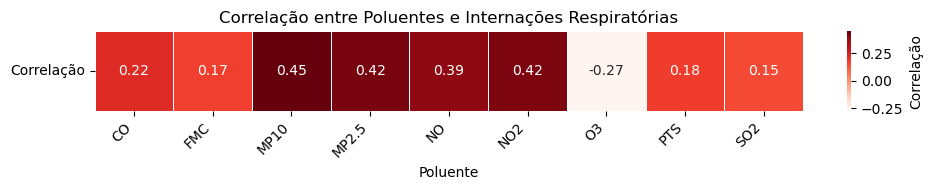

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectando ao DuckDB
con = duckdb.connect()

db = r"../dados/SP_poluicao_part*.parquet"

# Agrega média mensal de cada poluente
query = f"""
    SELECT 
        DATE_TRUNC('month', cast(Data as date)) AS Data,
        Poluente,
        AVG(Valor) AS media_valor
    FROM '{db}'
    GROUP BY 1, 2
"""
# Executa a Query no arquivo .parquet
df_pol_mes = con.execute(query).df()

# Pivota: transforma cada poluente em uma coluna
df_pol_pivot = df_pol_mes.pivot(index='Data', columns='Poluente', values='media_valor').reset_index()

# Conferindo se ambas as datas estão em datetime
df_pol_pivot['Data'] = pd.to_datetime(df_pol_pivot['Data'])
df_sus['Data'] = pd.to_datetime(df_sus['Data'])  # df_sus precisa estar carregado antes!

# Junta poluentes e internações
df_merged = pd.merge(df_pol_pivot, df_sus, on='Data', how='inner')

# Matriz de correlação
correlacao = df_merged.corr(numeric_only=True)

# Verifica os Valores das correlações
print(correlacao['Vlr_Internacoes'].sort_values(ascending=False))

# Filtra a matriz de correlação: apenas poluentes em relação às internações
correlacao_poluentes = correlacao[['Vlr_Internacoes']].drop(index='Vlr_Internacoes').reset_index()
correlacao_poluentes.columns = ['Poluente', 'Correlação']

# Plotando o heatmap usando matplotlib + seaborn
plt.figure(figsize=(10, 2))
heatmap_data = correlacao_poluentes.set_index('Poluente').T

sns.heatmap(
    heatmap_data,
    annot=True,          # Mostra os valores
    cmap='Reds',          # Escala de cores vermelha
    cbar_kws={'label': 'Correlação'},  # Nome da barra de cor
    linewidths=0.5,       # Linhas divisórias finas
    fmt=".2f"             # Formato dos números
)

plt.title('Correlação entre Poluentes e Internações Respiratórias')
plt.yticks(rotation=0)  # Mantém "Internações" horizontal
plt.xticks(rotation=45, ha='right')  # Inclina os poluentes para melhor leitura
plt.tight_layout()
plt.show()


Podemos perceber acima que os poluentes MP10, MP2.5 e NO2 têm maior correlação com o número de internações por causas respiratórias.

# **Modelo base**

Como discutido em Parmezan, Souza e Batista (2019) alguns modelos são mais promissores que outros. O único modelo estatístico que se destaca é o SARIMA, enquanto em modelos de aprendizado de máquina temos uma vasta seleção. Por simplicidade de treinamento, dado que não temos acessos a clusters e hardwares avançados, escolhemos os modelos SVM e KNN como base.

Por estar correlacionado a um aumento de doenças respiratórias, escolhemos o poluente MP10 como marcador-chave e o posto de medição Cerqueira César, por conter medições de MP10 e estar no centro expandido na cidade de São Paulo, o que pode ser usado como proxy para o nível de poluição na cidade como um todo.

Test MSE for MP10: 119.5376


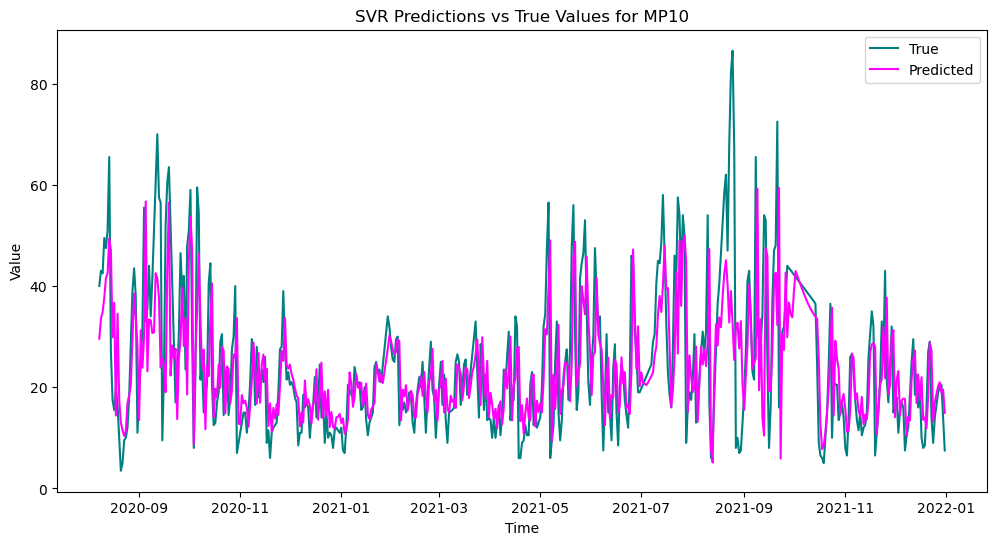

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

#1. Filter data for MP10 and Tatuapé
poluicao_sp['Data'] = pd.to_datetime(poluicao_sp['Data'])
df_mp10 = poluicao_sp[(poluicao_sp['Poluente'] == 'MP10') & (poluicao_sp['Estacao'] == 'Cerqueira César')]
df_mp10.set_index('Data', inplace=True)
df_mp10 = df_mp10[['Valor']].sort_index()
df_mp10 = df_mp10.resample('D').median().interpolate(method='linear')

df_mp10.tail()

#2. Prepare data for supervised learning
def series_to_supervised(data, n_lags):
    """
    Transform a 1D array into supervised learning format with lagged features.
    """
    df = pd.DataFrame({'y': data})
    for lag in range(1, n_lags + 1):
        df[f'y(t-{lag})'] = df['y'].shift(lag)
    return df.dropna()

n_lags = 5
df_mp10_supervised = series_to_supervised(df_mp10['Valor'].values, n_lags)
X_mp10 = df_mp10_supervised.drop('y', axis=1).values
y_mp10 = df_mp10_supervised['y'].values

#3. Train-test split
split_idx = int(len(X_mp10) * 0.8)
X_train_mp10, X_test_mp10 = X_mp10[:split_idx], X_mp10[split_idx:]
y_train_mp10, y_test_mp10 = y_mp10[:split_idx], y_mp10[split_idx:]

#4. Scale features and target
scaler_X_mp10 = StandardScaler().fit(X_train_mp10)
scaler_y_mp10 = StandardScaler().fit(y_train_mp10.reshape(-1, 1))
X_train_mp10_s = scaler_X_mp10.transform(X_train_mp10)
X_test_mp10_s = scaler_X_mp10.transform(X_test_mp10)
y_train_mp10_s = scaler_y_mp10.transform(y_train_mp10.reshape(-1, 1)).ravel()

#5. Train SVR
model_mp10 = SVR(kernel='rbf', C=10, epsilon=0.01)
model_mp10.fit(X_train_mp10_s, y_train_mp10_s)

#6. Predict and compute MSE
y_pred_mp10_s = model_mp10.predict(X_test_mp10_s)
y_pred_mp10 = scaler_y_mp10.inverse_transform(y_pred_mp10_s.reshape(-1, 1)).ravel()
mse_mp10 = mean_squared_error(y_test_mp10, y_pred_mp10)
print(f'Test MSE for MP10: {mse_mp10:.4f}')

#7. Plot predictions and the original series
plt.figure(figsize=(12, 6))
plt.plot(df_mp10.index[split_idx+5:], y_test_mp10, label='True', color='teal')
plt.plot(df_mp10.index[split_idx+5:], y_pred_mp10, label='Predicted', color='magenta')
plt.title('SVR Predictions vs True Values for MP10')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

Percebemos que o modelo SVR tem uma boa performance na largada, sem que mesmo tenhamos que pesqisar por parâmetros otimizados do modelo. A curva predita se assemelha bastante à curva real no dados de teste. Percebemos que o modelo SVR é robusto e consegue acompanhar bem variações sazoanais e diárias com baixo esforço do usuário.

Test MSE for KNN: 119.0579


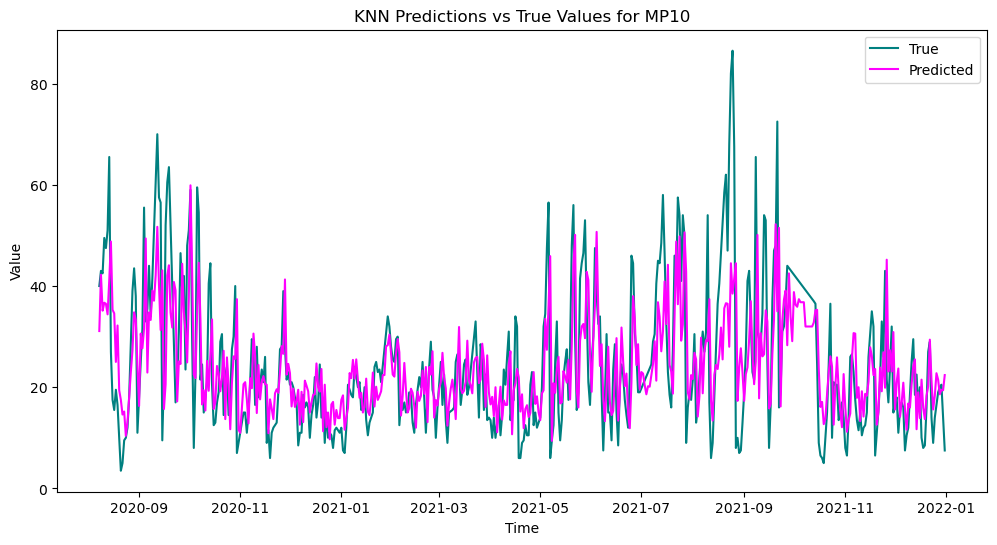

In [7]:
from sklearn.neighbors import KNeighborsRegressor

#2. Prepare data for supervised learning
n_lags = 5
df_mp10_supervised = series_to_supervised(df_mp10['Valor'].values, n_lags)
X_mp10 = df_mp10_supervised.drop('y', axis=1).values
y_mp10 = df_mp10_supervised['y'].values

#3. Train-test split (saving 20% for testing)
split_idx = int(len(X_mp10) * 0.8)
X_train_mp10, X_test_mp10 = X_mp10[:split_idx], X_mp10[split_idx:]
y_train_mp10, y_test_mp10 = y_mp10[:split_idx], y_mp10[split_idx:]

#4. Scale features and target
scaler_X_mp10 = StandardScaler().fit(X_train_mp10)
scaler_y_mp10 = StandardScaler().fit(y_train_mp10.reshape(-1, 1))
X_train_mp10_s = scaler_X_mp10.transform(X_train_mp10)
X_test_mp10_s = scaler_X_mp10.transform(X_test_mp10)
y_train_mp10_s = scaler_y_mp10.transform(y_train_mp10.reshape(-1, 1)).ravel()

#5. Train KNN
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_mp10_s, y_train_mp10_s)

#6. Predict and compute MSE
y_pred_knn_s = model_knn.predict(X_test_mp10_s)
y_pred_knn = scaler_y_mp10.inverse_transform(y_pred_knn_s.reshape(-1, 1)).ravel()
mse_knn = mean_squared_error(y_test_mp10, y_pred_knn)
print(f'Test MSE for KNN: {mse_knn:.4f}')

#7. Plot predictions and the original series
plt.figure(figsize=(12, 6))
plt.plot(df_mp10.index[split_idx+5:], y_test_mp10, label='True', color='teal')
plt.plot(df_mp10.index[split_idx+5:], y_pred_knn, label='Predicted', color='magenta')
plt.title('KNN Predictions vs True Values for MP10')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

Da mesma forma, percebemos que o modelo KNN tem uma boa performance, sem a necessidade pesqisar por parâmetros otimizados (como o número de vizinhos). 

Isso confirma o que já tinha sido eposto em Parmezan, Souza e Batista (2019).

/Users/victor.teodoro/miniforge3/envs/proj-aplicado-iv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Test MSE: 237.3672


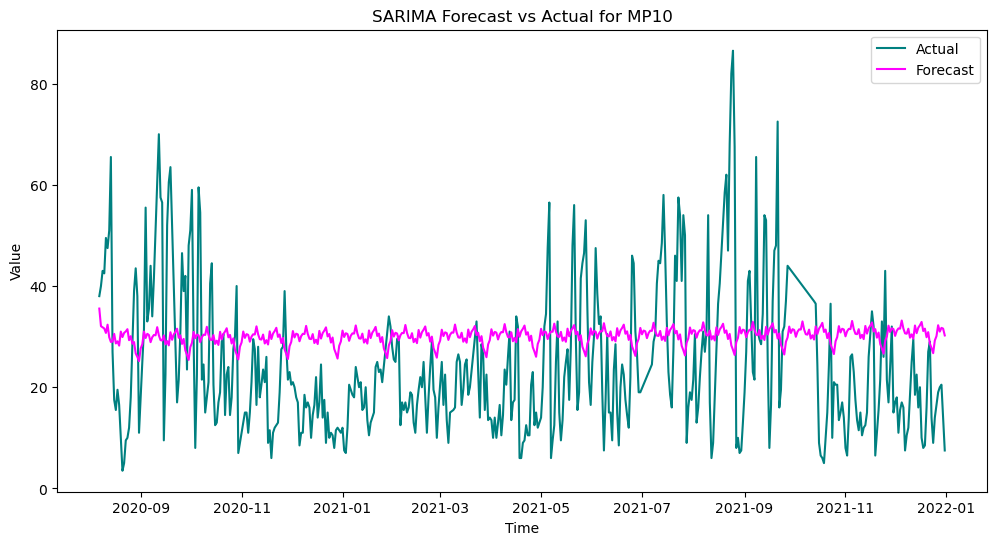

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 3. Split into train/test (20% test), use df_mp10['Valor'] for the series
series = df_mp10['Valor'].values
split_idx = int(len(df_mp10['Valor'].values) * 0.8)
train, test = series[:split_idx], series[split_idx:]

# 4. Train SARIMA model
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 30))
model_fit = model.fit(disp=False)

# 5. Forecast
forecast = model_fit.forecast(steps=len(test))

# 7. Compute MSE
mse = mean_squared_error(test, forecast)
print(f'Test MSE: {mse:.4f}')

# 8. Plot forecast vs actual
plt.figure(figsize=(12, 6))
plt.plot(df_mp10.index[split_idx:], test, label='Actual', color='teal')
plt.plot(df_mp10.index[split_idx:], forecast, label='Forecast', color='magenta')
plt.title('SARIMA Forecast vs Actual for MP10')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


O modelo SARIMAX por outro lado teve uma performance incial bastante ruim como podemos notar acima. Isso porque o modelo exige uma pesquisa muito mais detalhada por parâmetros ótimos (p, d, q) e (P, D, Q, s). Logo é um modelo promissor na literatura mas que exige mais esforço do usuário incialmente.

Portanto recomendamos seguir com modelos de aprendizado de máquina daqui em diante por sua facilidade de uso e qualidade das previsões.

# Resultado parcial

Como previsto em (BRAGA et al., 2001), percebemos que existe uma correlação entre o nível de alguns poluentes na atmosfera e o nível de internações hospitalares por causas repiratórias. Prever dias com alto nível de poluentes atmosféricos é uma forma de prevenir complicações de saúde na população, especialmente em camadas mais vulneráveis como crianças e idosos.

Pudemos confirmar, como descrito na literatura, que modelos de aprendizado de máquina têm uma performance melhor na predição de valores de séries temporais com um nível de esforço mais baixo. Portanto decidimos continuar refinando os modelos de aprendizado de máquina investigados, SVM e KNN. Na próxima entrega podemos investigar o efeito de diferentes parâmetros na performance desses modelos, como o número de lags temporais analisados, número de vizinhos, &c.

Porém já foi possível conseguir uma boa performance e replicar de forma próxima o comportamento real da curva de poluentes, o que já nos permite predizer dias con níveis extremos de poluentes.

# **Cronograma**

### **1. Referencial Teórico e Cronograma** (28/03)

| **Atividade**                                                | **Data de Término** |
|--------------------------------------------------------------|---------------------|
| Finalizar revisão da literatura e definir estrutura do referencial teórico | 19/03               |
| Criar esboço do pipeline da solução e revisar cronograma inicial | 20/03               |
| Reunião de alinhamento para discussão do referencial teórico, pipeline e cronograma | 22/03               |
| Ajustes finais no referencial teórico e documentação do pipeline | 27/03               |
| Entrega da versão final do referencial teórico, pipeline e cronograma detalhado | 28/03               |

### **2. Implementação Parcial** (25/04)

| **Atividade**                                                | **Data de Término** |
|--------------------------------------------------------------|---------------------|
| Revisão de progresso e definição do modelo base a ser implementado | 16/04               |
| Análise exploratória dos dados e preparação dos dados (limpeza, normalização, etc.) | 20/04               |
| Implementação e testes de modelos base (ARIMA, XGBoost, LSTM, etc.) | 23/04               |
| Finalização do notebook e revisão do cronograma com atividades futuras | 24/04               |
| Entrega do notebook, análise exploratória e modelo base com cronograma atualizado | 25/04               |

### **3. Implementação e Entrega Final** (30/05)

| **Atividade**                                                | **Data de Término** |
|--------------------------------------------------------------|---------------------|
| Preparação do repositório GitHub com todos os artefatos, dados e documentação | 23/05               |
| Produção e gravação do vídeo de apresentação do projeto      | 27/05               |
| Revisão final do notebook do projeto e ajustes no artigo científico | 28/05               |
| Submissão do GitHub, vídeo, notebook e artigo final          | 29/05               |
| Entrega final do projeto com todos os artefatos e apresentação completa | 30/05               |

# **Referências**

BRAGA, A. L. F.; PEREIRA, L. A. A.; SALDIVA, P. H. N. Poluição atmosférica e saúde pública. *Jornal de Pneumologia*, v. 27, n. 1, p. 10-15, 2001.

CETESB - Companhia Ambiental do Estado de São Paulo. *Relatório de Qualidade do Ar no Estado de São Paulo*. São Paulo: CETESB, 2022. Disponível em: [https://cetesb.sp.gov.br](https://cetesb.sp.gov.br). Acesso em: 27 fev. 2025.

GOUVEIA, N.; FLETCHER, T. Respiratory diseases in children and outdoor air pollution in São Paulo, Brazil - a time series analysis. Occupational and Environmental Medicine, v. 57, p. 477-483, 2000.

JALILI, M. et al. Relationship of Air Pollution and Daily Hospital Admissions Due to Respiratory Disease: A Time Series Analysis. *Journal of Environmental Health and Sustainable Development*, v. 5, n. 1, p. 971-80, 2020.

MONTERO-MANSO, Pablo; HYNDMAN, Rob J. Evaluation of statistical and machine learning models for time series prediction. *International Journal of Forecasting*, v. 36, n. 1, p. 168–188, 2020. DOI: [https://doi.org/10.1016/j.ijforecast.2019.05.011](https://doi.org/10.1016/j.ijforecast.2019.05.011).

PARMEZAN, Antonio Rafael Sabino; SOUZA, Vinicius M.A.; BATISTA, Gustavo E.A.P.A. *Evaluation of statistical and machine learning models for time series prediction: Identifying the state-of-the-art and the best conditions for the use of each model*. *Information Sciences*, 2019. DOI: [https://doi.org/10.1016/j.ins.2019.01.076](https://doi.org/10.1016/j.ins.2019.01.076).

SLAMA, A. et al. Impact of air pollution on hospital admissions with a focus on respiratory diseases - a time-series multi-city analysis. *Environmental Science and Pollution Research*, v. 26, p. 16998–17009, 2019.

WHO - World Health Organization. Air Pollution and Health. 2021. Disponível em: [https://www.who.int/news-room/fact-sheets/detail/ambient-(outdoor)-air-quality-and-health](https://www.who.int/news-room/fact-sheets/detail/ambient-(outdoor)-air-quality-and-health). Acesso em: 27 fev. 2025.

ZHANG, Yang; BOCQUET, Marc; MALLET, Vivien; SEIGNEUR, Christian; BAKLANOV, Alexander. Real-time air quality forecasting, part I: history, techniques, and current status. *Atmospheric Environment*, v. 60, p. 632–655, 2012. DOI: [https://doi.org/10.1016/j.atmosenv.2012.06.031](https://doi.org/10.1016/j.atmosenv.2012.06.031).trega anterior.




In [2]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

Revisao = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao_geral = 10 #@param {type:"slider", min:0, max:10, step:1}








In [3]:
#@title **Nota Final**
nota = 0.4*EDA_e_preprocessamento + 0.2*Modelo_base + 0.2*Revisao + 0.2*Apresentacao_geral

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
